#Install and Import libraries

In [3]:
# Import required libraries

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


Load Titanic exactly ONCE

In [4]:
# Load the Titanic dataset exactly once.
# Do not use sns.load_dataset("titanic") anywhere else in this project.

titanic_raw_df = sns.load_dataset("titanic")

print("Titanic dataset loaded successfully.")
print(f"Dataset shape: {titanic_raw_df.shape}")

Titanic dataset loaded successfully.
Dataset shape: (891, 15)


# Create a working copy

In [5]:
# Create a working copy of the original dataset.

df = titanic_raw_df.copy()

print("Working DataFrame created.")

Working DataFrame created.


Check df.info()

In [6]:
# Display dataset structure and data types.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


# Check df.describe()

In [7]:
# Display descriptive statistics for numeric columns.

df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Display dataset shape

In [8]:
# Display number of rows and columns.

print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset shape: (891, 15)
Number of rows: 891
Number of columns: 15


# Calculate missing values

In [9]:
# Calculate missing values and missing-value percentages.

missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_summary_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage
})

# Keep only columns containing missing values.
affected_columns_df = missing_summary_df[
    missing_summary_df["missing_count"] > 0
].sort_values(
    by="missing_percentage",
    ascending=False
)

print("Missing-value summary:")
display(affected_columns_df)

Missing-value summary:


,missing_count,missing_percentage
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


# Check class balance

In [10]:
# Check survival class distribution.

survival_count = df["survived"].value_counts().sort_index()

survival_percentage = (
    df["survived"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

class_balance_df = pd.DataFrame({
    "count": survival_count,
    "percentage": survival_percentage
})

class_balance_df.index = [
    "Not Survived (0)",
    "Survived (1)"
]

print("Survival class balance:")
display(class_balance_df)

Survival class balance:


,count,percentage
Not Survived (0),549,61.62
Survived (1),342,38.38


# Show first five rows

In [11]:
# Preview the dataset.

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Task 1 — Dataset Profiling

The Titanic dataset was loaded once using Seaborn's `sns.load_dataset("titanic")`.
The dataset contains passenger information that will be used throughout both the EDA
and predictive-modeling stages.

The dataset was profiled using `df.info()`, `df.describe()`, and `df.shape`. Missing-value
percentages were calculated for every affected column so that the cleaning decisions in
Task 2 can follow the required percentage-based threshold rule.

The survival target was also inspected to understand its class distribution. This class
balance will later be used to justify a stratified train/test split.

# Task 2 — Missing-Value Handling

# Save the required offline fallback

In [12]:
# Save the originally loaded Titanic dataset as the required offline fallback.

df.to_csv("titanic.csv", index=False)

print("titanic.csv saved successfully.")

titanic.csv saved successfully.


# Verify the CSV exists

In [13]:
# Verify that the offline fallback file exists.

import os

if os.path.exists("titanic.csv"):
    print("Verification successful: titanic.csv exists.")
else:
    print("ERROR: titanic.csv was not created.")

Verification successful: titanic.csv exists.


Add Task 2 heading

## Task 2 — Missing-Value Handling

Missing values are handled according to the assignment's percentage-based threshold rule:

- Less than 5% missing → drop affected rows.
- Between 5% and 30% missing → impute missing values.
- More than 30% missing → drop the column or justify retaining it.

# Display exact missing percentages again

In [14]:
# Report exact missing percentages before applying any cleaning strategy.

missing_report_df = (
    df.isnull()
    .sum()
    .to_frame(name="missing_count")
)

missing_report_df["missing_percentage"] = (
    df.isnull().mean() * 100
).round(2)

missing_report_df = missing_report_df[
    missing_report_df["missing_count"] > 0
].sort_values(
    by="missing_percentage",
    ascending=False
)

display(missing_report_df)

,missing_count,missing_percentage
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


# Apply the required strategy

In [15]:
# Create a cleaned working DataFrame.
cleaned_df = df.copy()

# 1. More than 30% missing:
# Drop 'deck' because 77.22% of its values are missing.
cleaned_df = cleaned_df.drop(columns=["deck"])

# 2. Between 5% and 30% missing:
# Impute 'age' using the median.
age_median = cleaned_df["age"].median()
cleaned_df["age"] = cleaned_df["age"].fillna(age_median)

# 3. Less than 5% missing:
# Drop rows where 'embarked' or 'embark_town' is missing.
cleaned_df = cleaned_df.dropna(
    subset=["embarked", "embark_town"]
)

# Reset row index after dropping rows.
cleaned_df = cleaned_df.reset_index(drop=True)

print("Missing-value handling completed.")
print("Age median used for imputation:", age_median)
print("Original shape:", df.shape)
print("Cleaned shape:", cleaned_df.shape)

Missing-value handling completed.
Age median used for imputation: 28.0
Original shape: (891, 15)
Cleaned shape: (889, 14)


# Verify that cleaning worked

In [16]:
# Verify missing values after Task 2 cleaning.

remaining_missing = cleaned_df.isnull().sum()

print("Remaining missing values:")
print(remaining_missing[remaining_missing > 0])

print("\nTotal remaining missing values:",
      cleaned_df.isnull().sum().sum())

Remaining missing values:
Series([], dtype: int64)

Total remaining missing values: 0


# Verify the column and row changes

In [17]:
print("Original columns:", df.shape[1])
print("Cleaned columns:", cleaned_df.shape[1])

print("\nRows removed:", len(df) - len(cleaned_df))

print("\n'deck' present:",
      "deck" in cleaned_df.columns)

Original columns: 15
Cleaned columns: 14

Rows removed: 2

'deck' present: False


# Add the required written justification

### Missing-Value Strategy and Justification

The missing-value percentages were measured before cleaning. The `deck` column had
77.22% missing values, which is above the 30% threshold. It was therefore dropped
because imputing such a large portion of the column would be unreliable.

The `age` column had 19.87% missing values, which falls within the 5%–30% imputation
range. Missing ages were replaced with the median age. Median imputation was chosen
because it is less sensitive to extreme values than the mean.

The `embarked` and `embark_town` columns each had only 0.22% missing values. Since
this is below the 5% threshold, the affected rows were removed.

After applying these strategies, the cleaned DataFrame contains no remaining missing
values and will be used for the subsequent exploratory data analysis.

# Make cleaned_df our main EDA dataset

In [18]:
# Use the cleaned DataFrame for all subsequent EDA tasks.

eda_df = cleaned_df.copy()

print("EDA dataset ready.")
print("EDA shape:", eda_df.shape)

EDA dataset ready.
EDA shape: (889, 14)


## Task 3 — Univariate Analysis of Age and Fare

This section examines the individual distributions of `age` and `fare`.
Histograms show the overall distribution, while box plots help identify potential
outliers. Outliers are formally counted using the IQR rule.

# Age Histogram

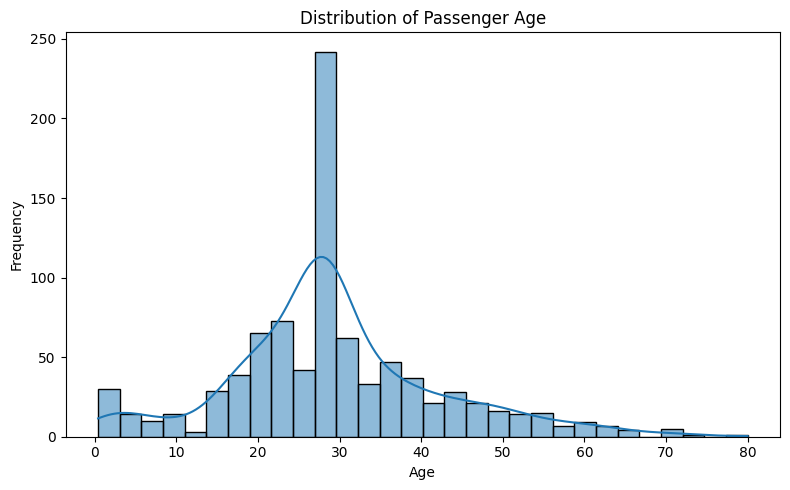

In [19]:
# Plot histogram for age.

plt.figure(figsize=(8, 5))

sns.histplot(
    data=eda_df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#Age Box Plot

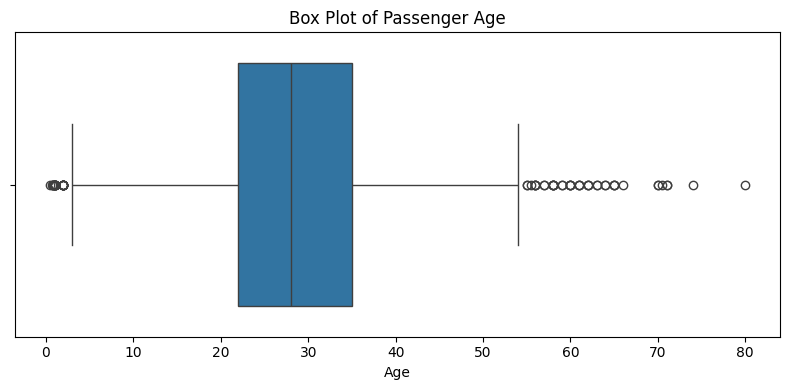

In [20]:
# Plot box plot for age.

plt.figure(figsize=(8, 4))

sns.boxplot(
    data=eda_df,
    x="age"
)

plt.title("Box Plot of Passenger Age")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

# Fare Histogram

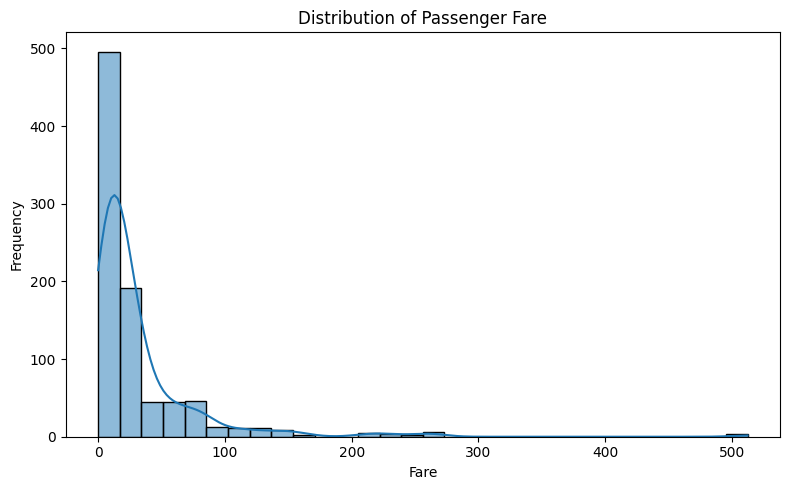

In [21]:
# Plot histogram for fare.

plt.figure(figsize=(8, 5))

sns.histplot(
    data=eda_df,
    x="fare",
    bins=30,
    kde=True
)

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Fare Box Plot

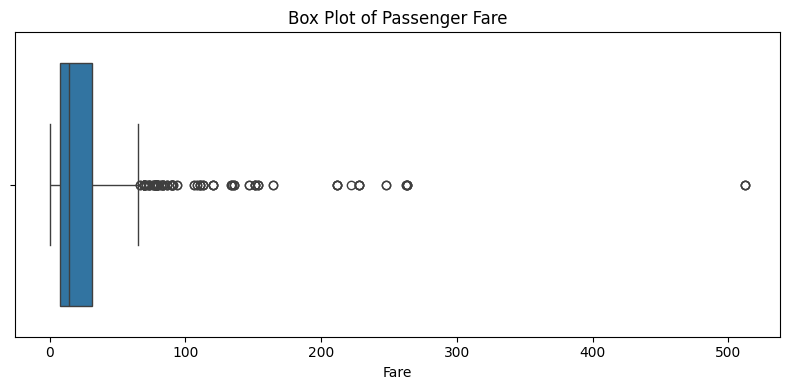

In [22]:
# Plot box plot for fare.

plt.figure(figsize=(8, 4))

sns.boxplot(
    data=eda_df,
    x="fare"
)

plt.title("Box Plot of Passenger Fare")
plt.xlabel("Fare")
plt.tight_layout()
plt.show()

# Create an IQR outlier function

In [23]:
# Function to calculate IQR-based outliers.

def calculate_iqr_outliers(dataframe, column_name):
    q1 = dataframe[column_name].quantile(0.25)
    q3 = dataframe[column_name].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outliers = dataframe[
        (dataframe[column_name] < lower_bound)
        | (dataframe[column_name] > upper_bound)
    ]

    return q1, q3, iqr, lower_bound, upper_bound, len(outliers)

#Calculate Age Outliers

In [24]:
# Calculate IQR(Interquartile Range) outliers for age.

(
    age_q1,
    age_q3,
    age_iqr,
    age_lower_bound,
    age_upper_bound,
    age_outlier_count
) = calculate_iqr_outliers(
    eda_df,
    "age"
)

print(f"Age Q1: {age_q1:.2f}")
print(f"Age Q3: {age_q3:.2f}")
print(f"Age IQR: {age_iqr:.2f}")
print(f"Age lower bound: {age_lower_bound:.2f}")
print(f"Age upper bound: {age_upper_bound:.2f}")
print(f"Number of age outliers: {age_outlier_count}")

Age Q1: 22.00
Age Q3: 35.00
Age IQR: 13.00
Age lower bound: 2.50
Age upper bound: 54.50
Number of age outliers: 65


#Calculate Fare Outliers

In [25]:
# Calculate IQR outliers for fare.

(
    fare_q1,
    fare_q3,
    fare_iqr,
    fare_lower_bound,
    fare_upper_bound,
    fare_outlier_count
) = calculate_iqr_outliers(
    eda_df,
    "fare"
)

print(f"Fare Q1: {fare_q1:.2f}")
print(f"Fare Q3: {fare_q3:.2f}")
print(f"Fare IQR: {fare_iqr:.2f}")
print(f"Fare lower bound: {fare_lower_bound:.2f}")
print(f"Fare upper bound: {fare_upper_bound:.2f}")
print(f"Number of fare outliers: {fare_outlier_count}")

Fare Q1: 7.90
Fare Q3: 31.00
Fare IQR: 23.10
Fare lower bound: -26.76
Fare upper bound: 65.66
Number of fare outliers: 114


# Fare Mean, Median and Mode

In [26]:
# Calculate mean, median and mode for fare.

fare_mean = eda_df["fare"].mean()
fare_median = eda_df["fare"].median()
fare_mode = eda_df["fare"].mode().iloc[0]

print(f"Fare mean: {fare_mean:.2f}")
print(f"Fare median: {fare_median:.2f}")
print(f"Fare mode: {fare_mode:.2f}")

Fare mean: 32.10
Fare median: 14.45
Fare mode: 8.05


# Calculate skewness too

In [27]:
# Calculate fare skewness.

fare_skewness = eda_df["fare"].skew()

print(f"Fare skewness: {fare_skewness:.2f}")


# Skewness ≈ 0
# → approximately symmetric

# Skewness > 0
# → right-skewed

# Skewness < 0
# → left-skewed

Fare skewness: 4.80


# Create a small summary table

In [28]:
# Create Task 3 summary table.

univariate_summary_df = pd.DataFrame({
    "feature": ["age", "fare"],
    "Q1": [age_q1, fare_q1],
    "Q3": [age_q3, fare_q3],
    "IQR": [age_iqr, fare_iqr],
    "lower_bound": [
        age_lower_bound,
        fare_lower_bound
    ],
    "upper_bound": [
        age_upper_bound,
        fare_upper_bound
    ],
    "outlier_count": [
        age_outlier_count,
        fare_outlier_count
    ]
})

display(
    univariate_summary_df.round(2)
)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,age,22.0,35.0,13.0,2.50,54.50,65
1,fare,7.9,31.0,23.1,-26.76,65.66,114


# Add written interpretation

In [29]:
# Generate the required written interpretation from calculated values.

print("TASK 3 INTERPRETATION")
print("-" * 50)

print(
    f"Using the IQR rule, age contains "
    f"{age_outlier_count} outliers, while fare contains "
    f"{fare_outlier_count} outliers."
)

print(
    f"The fare distribution has a mean of {fare_mean:.2f}, "
    f"a median of {fare_median:.2f}, and a mode of "
    f"{fare_mode:.2f}."
)

if fare_skewness > 0:
    print(
        "Fare is right-skewed because its skewness is positive "
        "and the mean is higher than the median."
    )
elif fare_skewness < 0:
    print(
        "Fare is left-skewed because its skewness is negative."
    )
else:
    print(
        "Fare is approximately symmetric because its "
        "skewness is close to zero."
    )

TASK 3 INTERPRETATION
--------------------------------------------------
Using the IQR rule, age contains 65 outliers, while fare contains 114 outliers.
The fare distribution has a mean of 32.10, a median of 14.45, and a mode of 8.05.
Fare is right-skewed because its skewness is positive and the mean is higher than the median.


# Task 3 checklist

✅ Age histogram
✅ Age box plot
✅ Fare histogram
✅ Fare box plot
✅ IQR formula implemented
✅ Age outlier count
✅ Fare outlier count
✅ Fare mean
✅ Fare median
✅ Fare mode
✅ Fare skewness
✅ Written interpretation

## Task 4 — Bivariate Analysis and Correlation

This section examines how passenger survival varies with sex and passenger class.
It also studies relationships among the six specified numeric variables using a
correlation matrix and heatmap.

# Survival Rate by Sex

In [30]:
# Calculate survival rate by sex using boolean masking.

sex_survival_results = []

for sex_value in eda_df["sex"].unique():
    mask = eda_df["sex"] == sex_value

    passenger_count = mask.sum()
    survival_rate = eda_df.loc[mask, "survived"].mean()

    sex_survival_results.append({
        "sex": sex_value,
        "passenger_count": passenger_count,
        "survival_rate": survival_rate
    })

sex_survival_df = pd.DataFrame(sex_survival_results)

sex_survival_df["survival_rate_percent"] = (
    sex_survival_df["survival_rate"] * 100
).round(2)

display(sex_survival_df)

,sex,passenger_count,survival_rate,survival_rate_percent
0,male,577,0.188908,18.89
1,female,312,0.740385,74.04


# Survival Rate by Passenger Class

In [31]:
# Calculate survival rate by passenger class using boolean masking.

pclass_survival_results = []

for class_value in sorted(eda_df["pclass"].unique()):
    mask = eda_df["pclass"] == class_value

    passenger_count = mask.sum()
    survival_rate = eda_df.loc[mask, "survived"].mean()

    pclass_survival_results.append({
        "pclass": class_value,
        "passenger_count": passenger_count,
        "survival_rate": survival_rate
    })

pclass_survival_df = pd.DataFrame(pclass_survival_results)

pclass_survival_df["survival_rate_percent"] = (
    pclass_survival_df["survival_rate"] * 100
).round(2)

display(pclass_survival_df)

,pclass,passenger_count,survival_rate,survival_rate_percent
0,1,214,0.626168,62.62
1,2,184,0.472826,47.28
2,3,491,0.242363,24.24


# Survival by Sex AND Passenger Class

In [32]:
# Calculate survival rate for every sex + pclass combination.

sex_pclass_results = []

for sex_value in eda_df["sex"].unique():
    for class_value in sorted(eda_df["pclass"].unique()):

        mask = (
            (eda_df["sex"] == sex_value)
            & (eda_df["pclass"] == class_value)
        )

        passenger_count = mask.sum()

        if passenger_count > 0:
            survival_rate = eda_df.loc[
                mask,
                "survived"
            ].mean()

            sex_pclass_results.append({
                "sex": sex_value,
                "pclass": class_value,
                "passenger_count": passenger_count,
                "survival_rate": survival_rate
            })

sex_pclass_survival_df = pd.DataFrame(
    sex_pclass_results
)

sex_pclass_survival_df["survival_rate_percent"] = (
    sex_pclass_survival_df["survival_rate"] * 100
).round(2)

display(sex_pclass_survival_df)

,sex,pclass,passenger_count,survival_rate,survival_rate_percent
0,male,1,122,0.368852,36.89
1,male,2,108,0.157407,15.74
2,male,3,347,0.135447,13.54
3,female,1,92,0.967391,96.74
4,female,2,76,0.921053,92.11
5,female,3,144,0.500000,50.00


# Demonstrate | Boolean Masking

In [33]:
# Example of OR (|) boolean masking:
# Select passengers who travelled in first OR second class.

first_or_second_class_mask = (
    (eda_df["pclass"] == 1)
    | (eda_df["pclass"] == 2)
)

first_or_second_class_survival_rate = eda_df.loc[
    first_or_second_class_mask,
    "survived"
].mean()

print(
    "Survival rate for first OR second class passengers:",
    f"{first_or_second_class_survival_rate * 100:.2f}%"
)

Survival rate for first OR second class passengers: 55.53%


# Create Exact Correlation Dataset

In [34]:
# Select exactly the six numeric columns required by the assignment.

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_df = eda_df[
    correlation_columns
].copy()

print("Columns used for correlation:")
print(correlation_df.columns.tolist())

correlation_matrix = correlation_df.corr()

display(correlation_matrix.round(3))

Columns used for correlation:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']


,survived,pclass,age,sibsp,parch,fare
survived,1.000,-0.336,-0.070,-0.034,0.083,0.255
pclass,-0.336,1.000,-0.337,0.082,0.017,-0.548
age,-0.070,-0.337,1.000,-0.233,-0.171,0.094
sibsp,-0.034,0.082,-0.233,1.000,0.415,0.161
parch,0.083,0.017,-0.171,0.415,1.000,0.218
fare,0.255,-0.548,0.094,0.161,0.218,1.000


# Correlation Heatmap

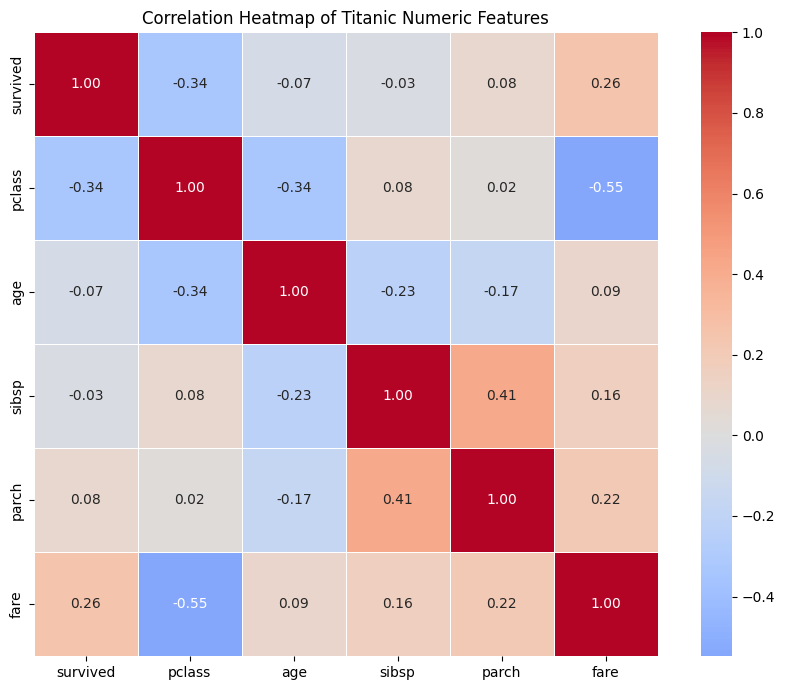

In [35]:
# Visualize the required 6x6 correlation matrix.

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Titanic Numeric Features"
)

plt.tight_layout()
plt.show()

# Find the TWO strongest correlations automatically

In [36]:
# Find the two strongest absolute off-diagonal correlations.

correlation_pairs = []

for i in range(len(correlation_columns)):
    for j in range(i + 1, len(correlation_columns)):

        feature_1 = correlation_columns[i]
        feature_2 = correlation_columns[j]

        correlation_value = correlation_matrix.loc[
            feature_1,
            feature_2
        ]

        correlation_pairs.append({
            "feature_1": feature_1,
            "feature_2": feature_2,
            "correlation": correlation_value,
            "absolute_correlation": abs(correlation_value)
        })

correlation_pairs_df = pd.DataFrame(
    correlation_pairs
).sort_values(
    by="absolute_correlation",
    ascending=False
).reset_index(drop=True)

top_two_correlations_df = correlation_pairs_df.head(2)

print("Two strongest off-diagonal correlations:")
display(top_two_correlations_df)

Two strongest off-diagonal correlations:


,feature_1,feature_2,correlation,absolute_correlation
0,pclass,fare,-0.548193,0.548193
1,sibsp,parch,0.414542,0.414542


# Generate Survival Interpretation

In [37]:
# Generate survival-rate interpretation.

highest_sex_row = sex_survival_df.loc[
    sex_survival_df["survival_rate"].idxmax()
]

highest_class_row = pclass_survival_df.loc[
    pclass_survival_df["survival_rate"].idxmax()
]

highest_combination_row = sex_pclass_survival_df.loc[
    sex_pclass_survival_df["survival_rate"].idxmax()
]

print("SURVIVAL ANALYSIS")
print("-" * 60)

print(
    f"{highest_sex_row['sex'].capitalize()} passengers had "
    f"the higher survival rate at "
    f"{highest_sex_row['survival_rate_percent']:.2f}%."
)

print(
    f"Passenger class {int(highest_class_row['pclass'])} "
    f"had the highest survival rate at "
    f"{highest_class_row['survival_rate_percent']:.2f}%."
)

print(
    f"The highest sex-class combination was "
    f"{highest_combination_row['sex']}, "
    f"class {int(highest_combination_row['pclass'])}, "
    f"with a survival rate of "
    f"{highest_combination_row['survival_rate_percent']:.2f}%."
)

SURVIVAL ANALYSIS
------------------------------------------------------------
Female passengers had the higher survival rate at 74.04%.
Passenger class 1 had the highest survival rate at 62.62%.
The highest sex-class combination was female, class 1, with a survival rate of 96.74%.


# Generate correlation interpretation

In [38]:
# Generate interpretation of the two strongest correlations.

print("CORRELATION INTERPRETATION")
print("-" * 60)

for rank, row in top_two_correlations_df.iterrows():

    direction = (
        "positive"
        if row["correlation"] > 0
        else "negative"
    )

    print(
        f"{rank + 1}. {row['feature_1']} and "
        f"{row['feature_2']}: "
        f"correlation = {row['correlation']:.3f} "
        f"({direction} relationship)"
    )

CORRELATION INTERPRETATION
------------------------------------------------------------
1. pclass and fare: correlation = -0.548 (negative relationship)
2. sibsp and parch: correlation = 0.415 (positive relationship)


### Task 4 Interpretation

Survival rates differ substantially across passenger sex and passenger class, showing
that these characteristics were associated with a passenger's likelihood of survival.
The combined sex-and-class analysis provides additional detail by showing how these
two characteristics interact.

The correlation heatmap was calculated using exactly the six required numeric variables:
`survived`, `pclass`, `age`, `sibsp`, `parch`, and `fare`. The two strongest
off-diagonal relationships were identified by ranking the absolute correlation
coefficients rather than selecting them visually.

# Task 4 checklist


✅ Survival rate by sex
✅ Survival rate by pclass
✅ Survival rate by sex + pclass
✅ Boolean & demonstrated
✅ Boolean | demonstrated
✅ Exactly six correlation columns
✅ 6 × 6 correlation matrix
✅ Heatmap
✅ adult_male excluded
✅ alone excluded
✅ Top two correlations ranked by abs(correlation)
✅ Written interpretation

## Task 5 — Visual Data Story

The following visualizations tell a connected story about survival patterns in the
Titanic dataset. The charts examine overall survival, differences by sex and passenger
class, and the relationship between passenger age and survival.

# Chat 1: Overall Survival Count

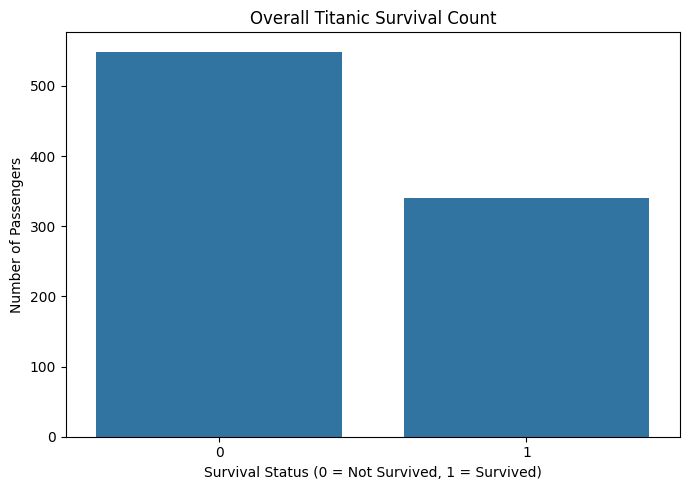

Not survived: 549
Survived: 340


In [39]:
# Chart 1: Overall survival count.

plt.figure(figsize=(7, 5))

sns.countplot(
    data=eda_df,
    x="survived"
)

plt.title("Overall Titanic Survival Count")
plt.xlabel("Survival Status (0 = Not Survived, 1 = Survived)")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

# Display exact values.
survival_counts = eda_df["survived"].value_counts().sort_index()

print("Not survived:", survival_counts.get(0, 0))
print("Survived:", survival_counts.get(1, 0))

### Chart 1 Interpretation

The chart shows that more passengers did not survive than survived. This indicates
that the target variable is moderately imbalanced rather than equally distributed.
This class distribution is important when splitting and evaluating the classification
models later in the project.

# Chart 2 — Survival Rate by Sex

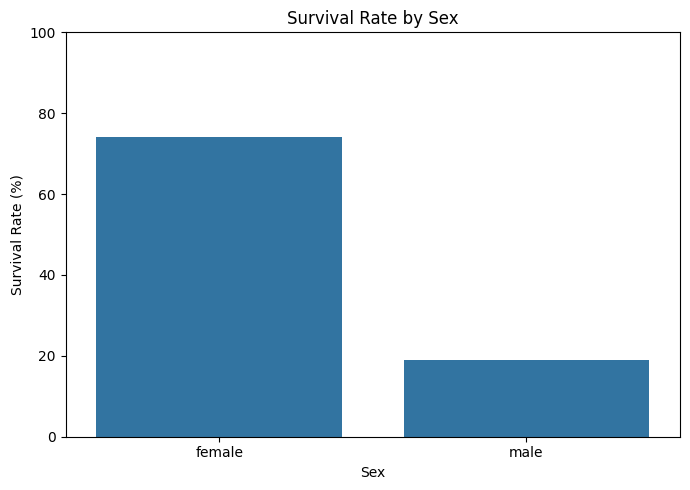

,sex,survival_rate_percent
0,female,74.04
1,male,18.89


In [40]:
# Chart 2: Survival rate by sex.

survival_by_sex_plot = (
    eda_df.groupby("sex", observed=True)["survived"]
    .mean()
    .reset_index()
)

survival_by_sex_plot["survival_rate_percent"] = (
    survival_by_sex_plot["survived"] * 100
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=survival_by_sex_plot,
    x="sex",
    y="survival_rate_percent"
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

display(
    survival_by_sex_plot[
        ["sex", "survival_rate_percent"]
    ].round(2)
)

### Chart 2 Interpretation

Female passengers had a substantially higher survival rate than male passengers.
The female survival rate was approximately 74%, showing a strong relationship between
sex and survival outcome. This suggests that `sex` may be an important predictive
feature in the later classification models.

Chart 3 — Survival Rate by Passenger Class

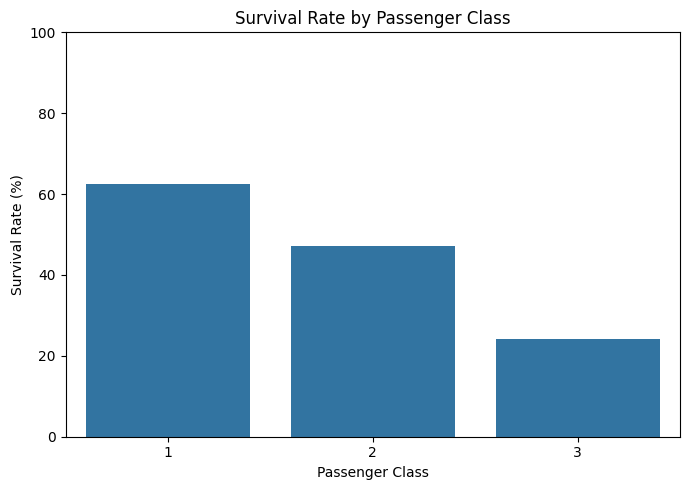

,pclass,survival_rate_percent
0,1,62.62
1,2,47.28
2,3,24.24


In [41]:
# Chart 3: Survival rate by passenger class.

survival_by_class_plot = (
    eda_df.groupby("pclass", observed=True)["survived"]
    .mean()
    .reset_index()
)

survival_by_class_plot["survival_rate_percent"] = (
    survival_by_class_plot["survived"] * 100
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=survival_by_class_plot,
    x="pclass",
    y="survival_rate_percent"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

display(
    survival_by_class_plot[
        ["pclass", "survival_rate_percent"]
    ].round(2)
)

### Chart 3 Interpretation

First-class passengers had the highest survival rate, while third-class passengers
had the lowest survival rate. First-class survival was approximately 62.62%.
The pattern suggests that passenger class was associated with survival and may
therefore provide useful predictive information for the classification models.

# Chart 4 — Age Distribution by Survival

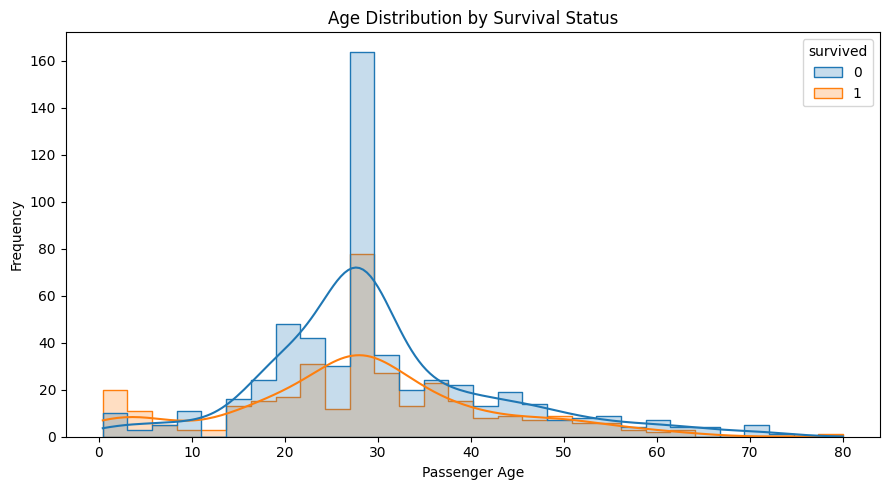

In [42]:
# Chart 4: Age distribution by survival status.

plt.figure(figsize=(9, 5))

sns.histplot(
    data=eda_df,
    x="age",
    hue="survived",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Passenger Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Calculate supporting age statistics

In [43]:
# Calculate mean and median age by survival status
# to support the chart interpretation.

age_by_survival = (
    eda_df.groupby("survived")["age"]
    .agg(["mean", "median", "count"])
    .round(2)
)

display(age_by_survival)

,mean,median,count
survived,,,
0,30.03,28.0,549
1,28.16,28.0,340


### Chart 4 Interpretation

The age distributions of survivors and non-survivors overlap considerably, indicating
that age alone does not completely separate the two survival outcomes. However, differences
can still be observed across portions of the age distribution. This suggests that age may
provide useful information when combined with stronger predictors such as sex and
passenger class.

# Chat 5: One more useful chart

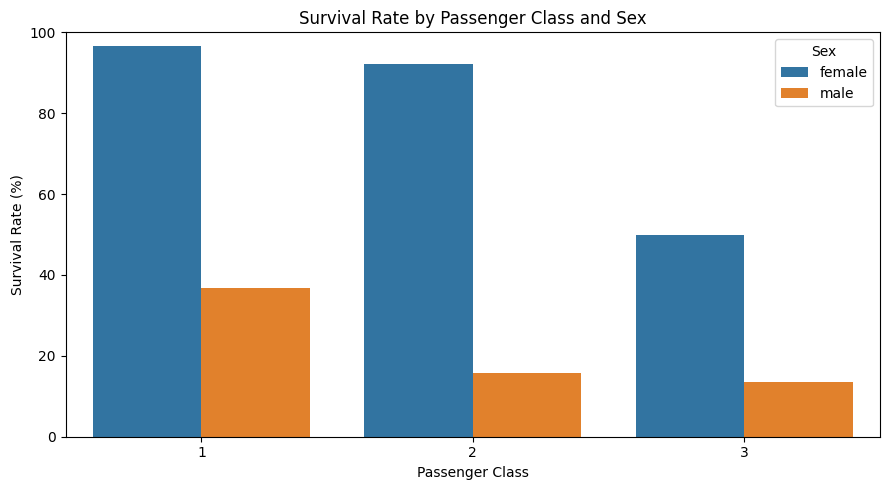

,pclass,sex,survival_rate_percent
0,1,female,96.74
1,1,male,36.89
2,2,female,92.11
3,2,male,15.74
4,3,female,50.00
5,3,male,13.54


In [44]:
# Chart 5: Survival rate by passenger class and sex.

sex_class_plot_df = (
    eda_df.groupby(
        ["pclass", "sex"],
        observed=True
    )["survived"]
    .mean()
    .reset_index()
)

sex_class_plot_df["survival_rate_percent"] = (
    sex_class_plot_df["survived"] * 100
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=sex_class_plot_df,
    x="pclass",
    y="survival_rate_percent",
    hue="sex"
)

plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.legend(title="Sex")
plt.tight_layout()
plt.show()

display(
    sex_class_plot_df[
        [
            "pclass",
            "sex",
            "survival_rate_percent"
        ]
    ].round(2)
)

### Chart 5 Interpretation

Combining sex and passenger class reveals a stronger survival pattern than examining
either characteristic alone. Female passengers generally show higher survival rates
across passenger classes, with first-class females having the highest observed survival
rate at approximately 96.74%. This interaction suggests that both sex and passenger
class should be considered during predictive modeling.

# Add overall EDA conclusion

# ### Overall Visual Story

The visual analysis shows that Titanic survival was not evenly distributed across
passengers. Sex and passenger class display particularly strong differences in survival,
while age provides additional but less distinct information when considered independently.

These findings provide a data-driven basis for the modeling stage. Features such as sex,
passenger class, age, fare, and family-related variables will therefore be considered as
potential predictors of survival.

## Task 6 — Standardization Sanity Check

The `age` and `fare` features are standardized to verify the effect of feature scaling.
After standardization, each feature should have a mean close to 0 and a standard
deviation close to 1.

In [45]:
# Import StandardScaler from scikit-learn.

from sklearn.preprocessing import StandardScaler

print("StandardScaler imported successfully.")

StandardScaler imported successfully.


# Keep original values safe

In [46]:
# Create a separate DataFrame for the standardization sanity check.
# The original EDA dataset remains unchanged.

standardization_df = eda_df[
    ["age", "fare"]
].copy()

display(standardization_df.head())

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


# Standardize Age and Fare

In [47]:
# Standardize age and fare.

scaler = StandardScaler()

scaled_values = scaler.fit_transform(
    standardization_df[["age", "fare"]]
)

standardization_df[
    ["age_standardized", "fare_standardized"]
] = scaled_values

display(standardization_df.head())

,age,fare,age_standardized,fare_standardized
0,22.0,7.2500,-0.563674,-0.500240
1,38.0,71.2833,0.669217,0.788947
2,26.0,7.9250,-0.255451,-0.486650
3,35.0,53.1000,0.438050,0.422861
4,35.0,8.0500,0.438050,-0.484133


# Verify Mean and Standard Deviation

In [48]:
# Verify standardized means and standard deviations.

standardization_summary_df = pd.DataFrame({
    "feature": [
        "age_standardized",
        "fare_standardized"
    ],
    "mean": [
        standardization_df["age_standardized"].mean(),
        standardization_df["fare_standardized"].mean()
    ],
    "std_ddof_0": [
        standardization_df["age_standardized"].std(ddof=0),
        standardization_df["fare_standardized"].std(ddof=0)
    ]
})

display(
    standardization_summary_df.round(6)
)

,feature,mean,std_ddof_0
0,age_standardized,0.0,1.0
1,fare_standardized,0.0,1.0


# Automatic verification


In [49]:
# Automatically verify the standardization result.

age_mean_close_to_zero = np.isclose(
    standardization_df["age_standardized"].mean(),
    0,
    atol=1e-10
)

fare_mean_close_to_zero = np.isclose(
    standardization_df["fare_standardized"].mean(),
    0,
    atol=1e-10
)

age_std_close_to_one = np.isclose(
    standardization_df["age_standardized"].std(ddof=0),
    1,
    atol=1e-10
)

fare_std_close_to_one = np.isclose(
    standardization_df["fare_standardized"].std(ddof=0),
    1,
    atol=1e-10
)

print(
    "Age mean approximately 0:",
    age_mean_close_to_zero
)

print(
    "Fare mean approximately 0:",
    fare_mean_close_to_zero
)

print(
    "Age standard deviation approximately 1:",
    age_std_close_to_one
)

print(
    "Fare standard deviation approximately 1:",
    fare_std_close_to_one
)

Age mean approximately 0: True
Fare mean approximately 0: True
Age standard deviation approximately 1: True
Fare standard deviation approximately 1: True


### Standardization Interpretation

After applying `StandardScaler`, both standardized features have means approximately
equal to 0 and standard deviations approximately equal to 1. This confirms that the
standardization was performed correctly.

The scaling performed here is only a sanity check and does not replace the preprocessing
pipeline used during predictive modeling. In the modeling notebook, preprocessing will
be fitted only on the training data to prevent data leakage.

# Final Notebook 1 verification

In [50]:
# Final verification for the EDA notebook.

print("=" * 60)
print("01_eda.ipynb FINAL VERIFICATION")
print("=" * 60)

print("Original Titanic shape:", df.shape)
print("Cleaned EDA shape:", eda_df.shape)

print(
    "Missing values in cleaned EDA:",
    eda_df.isnull().sum().sum()
)

print(
    "Offline fallback titanic.csv exists:",
    os.path.exists("titanic.csv")
)

print(
    "Original columns:",
    df.columns.tolist()
)

print(
    "\nEDA columns:",
    eda_df.columns.tolist()
)

print("=" * 60)
print("TASKS 1-6 COMPLETED")
print("=" * 60)

01_eda.ipynb FINAL VERIFICATION
Original Titanic shape: (891, 15)
Cleaned EDA shape: (889, 14)
Missing values in cleaned EDA: 0
Offline fallback titanic.csv exists: True
Original columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

EDA columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']
TASKS 1-6 COMPLETED


01_eda.ipynb

✅ Task 1 — Profiling
✅ Task 2 — Missing-value handling
✅ Task 3 — Univariate analysis
✅ Task 4 — Bivariate + correlation
✅ Task 5 — Visual data story
✅ Task 6 — Standardization sanity check

──────────────
Tasks 1–6 DONE
──────────────

In [51]:
print(titanic_raw_df.shape)

(891, 15)


# Save titanic.csv directly into the analytics folder

In [55]:
titanic_raw_df.to_csv(
    "/content/titanic.csv",
    index=False
)

print("titanic.csv created successfully.")

titanic.csv created successfully.


# Verify it

In [56]:
!ls -lh /content/titanic.csv

-rw-r--r-- 1 root root 56K Aug 11 08:23 /content/titanic.csv


# Save a permanent copy to Google Drive

In [57]:
import os

print(
    os.path.exists("/content/drive/MyDrive")
)

False


In [59]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Verify

In [60]:
import os

print(os.path.exists("/content/drive/MyDrive"))

True


# Save Titanic permanently to Drive

In [61]:
titanic_raw_df.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/titanic.csv",
    index=False
)

print("Titanic CSV saved to Google Drive.")

Titanic CSV saved to Google Drive.


In [62]:
!ls -lh "/content/drive/MyDrive/Colab Notebooks/titanic.csv"

-rw------- 1 root root 56K Aug 11 08:50 '/content/drive/MyDrive/Colab Notebooks/titanic.csv'


# copy titanic.csv from Drive into /analytics

In [63]:
!cp "/content/drive/MyDrive/Colab Notebooks/titanic.csv" \
"/content/Zepto-Data-AI-Platform/analytics/titanic.csv"

cp: cannot create regular file '/content/Zepto-Data-AI-Platform/analytics/titanic.csv': No such file or directory


In [64]:
!ls -lh "/content/Zepto-Data-AI-Platform/analytics/"

ls: cannot access '/content/Zepto-Data-AI-Platform/analytics/': No such file or directory


In [65]:
!pwd

/content


In [66]:
!ls -la /content

total 76
drwxr-xr-x 1 root root  4096 Aug 11 08:26 .
drwxr-xr-x 1 root root  4096 Aug 11 06:33 ..
drwxr-xr-x 4 root root  4096 Jun  4 13:32 .config
drwx------ 5 root root  4096 Aug 11 08:26 drive
drwxr-xr-x 1 root root  4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root 57018 Aug 11 08:23 titanic.csv


# Search for the repository

In [67]:
!find /content -maxdepth 3 -type d -name "Zepto-Data-AI-Platform" 2>/dev/null

/content/drive/MyDrive/Zepto-Data-AI-Platform


# Copy titanic.csv into the real analytics folder

In [68]:
!cp "/content/drive/MyDrive/Colab Notebooks/titanic.csv" \
"/content/drive/MyDrive/Zepto-Data-AI-Platform/analytics/titanic.csv"

cp: cannot create regular file '/content/drive/MyDrive/Zepto-Data-AI-Platform/analytics/titanic.csv': No such file or directory


# Show the repository contents

In [69]:
!ls -la "/content/drive/MyDrive/Zepto-Data-AI-Platform"

total 4
drwx------ 2 root root 4096 Jul 31 11:04 data_pipeline


In [71]:
!find /content -maxdepth 2 -type d -name ".git" -printf "%h\n" 2>/dev/null

In [72]:
!git clone https://github.com/sepurkrishna4-lgtm/Zepto-Data-AI-Platform.git

Cloning into 'Zepto-Data-AI-Platform'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 76 (delta 31), reused 33 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 94.52 KiB | 1.52 MiB/s, done.
Resolving deltas: 100% (31/31), done.


# Enter the repository

In [73]:
%cd /content/Zepto-Data-AI-Platform

/content/Zepto-Data-AI-Platform


# Verify Module 1 came from GitHub

In [75]:
!ls -la

total 36
drwxr-xr-x 6 root root 4096 Aug 11 09:07 .
drwxr-xr-x 1 root root 4096 Aug 11 09:07 ..
drwxr-xr-x 2 root root 4096 Aug 11 09:07 analytics
drwxr-xr-x 4 root root 4096 Aug 11 09:07 data_pipeline
drwxr-xr-x 8 root root 4096 Aug 11 09:07 .git
-rw-r--r-- 1 root root 4628 Aug 11 09:07 .gitignore
-rw-r--r-- 1 root root  120 Aug 11 09:07 README.md
drwxr-xr-x 2 root root 4096 Aug 11 09:07 support_assistant


In [76]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


# Create our Module 2 branch again

In [77]:
!git switch -c feature/analytics-pipeline

Switched to a new branch 'feature/analytics-pipeline'


In [78]:
!git branch

* feature/analytics-pipeline
  main


# Create analytics

In [79]:
!mkdir -p analytics

In [80]:
!ls

analytics  data_pipeline  README.md  support_assistant


# Copy the two notebooks from Google Drive

In [81]:
!cp "/content/drive/MyDrive/Colab Notebooks/01_eda.ipynb.ipynb" \
"/content/Zepto-Data-AI-Platform/analytics/01_eda.ipynb"

In [82]:
!cp "/content/drive/MyDrive/Colab Notebooks/02_modeling.ipynb" \
"/content/Zepto-Data-AI-Platform/analytics/02_modeling.ipynb"

# Copy titanic.csv

In [84]:
!cp "/content/drive/MyDrive/Colab Notebooks/titanic.csv" \
"/content/Zepto-Data-AI-Platform/analytics/titanic.csv"

In [85]:
!ls -lh analytics/

total 944K
-rw------- 1 root root 524K Aug 11 09:12 01_eda.ipynb
-rw------- 1 root root 358K Aug 11 09:12 02_modeling.ipynb
-rw-r--r-- 1 root root  159 Aug 11 09:07 README.md
-rw------- 1 root root  56K Aug 11 09:17 titanic.csv
